# <center>Organizaci&oacute;n de Datos</center>
#### <center>C&aacute;tedra Ing. Rodriguez, Juan Manuel </center>

## <center>Árboles de Decisión</center>
### <center> Práctica Búsqueda de Hiperparámetros </center>

## Links de interés



* [Trade off sesgo-varianza](http://www.r2d3.us/visual-intro-to-machine-learning-part-2/)
* [Documentación de la clase DecisionTreeClassifier de scikit-learn](https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html)
* [How to tune a Decision Tree in Hyperparameter tuning? - Geeks for Geeks](https://www.geeksforgeeks.org/how-to-tune-a-decision-tree-in-hyperparameter-tuning/)


## Objetivo

En esta notebook el objetivo es clasificar vinos segun su calidad (bueno /malo) utilizando árboles de decisón.

Para esto vamos a construir el "mejor" clasificador eligiendo los hiperparametros más adecuados mediante validación cruzada.

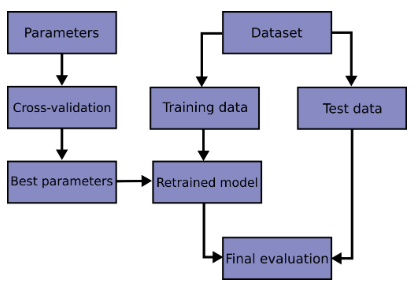

¿ A qué nos referimos con mejor?

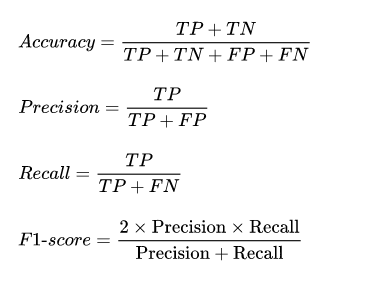

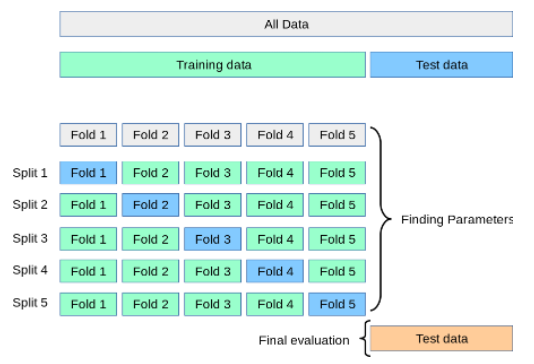

### ¿Por qué tunear hiperparámetros?

Ajustar los **hyperparameters** es crucial para los **decision trees** por las siguientes razones:

- **Mejora del rendimiento**: Los **hyperparameters** sin ajustar pueden llevar a **decision trees** subóptimos. El ajuste permite encontrar las configuraciones que mejor se adapten a tus datos, resultando en un modelo que captura los patrones subyacentes de manera más efectiva y ofrece mejores predicciones.
  
- **Reducción del overfitting**: Los **decision trees** son propensos al **overfitting**, donde el modelo memoriza el ruido de los datos de entrenamiento en lugar de aprender patrones generalizables. El ajuste de **hyperparameters** ayuda a prevenir esto al controlar la complejidad del árbol (por ejemplo, con **max_depth**) y evitar una granularidad excesiva (por ejemplo, con **min_samples_split**).

- **Mejora de la generalización**: El objetivo es que el **decision tree** funcione bien con datos no vistos. Ajustar los **hyperparameters** ayuda a lograr esto al encontrar un equilibrio entre la complejidad y la flexibilidad del modelo. Un árbol bien ajustado puede capturar las tendencias importantes en los datos sin **overfitting** en los detalles específicos del conjunto de entrenamiento, lo que mejora el rendimiento en datos nuevos.

- **Abordar el desequilibrio de clases**: El desequilibrio de clases ocurre cuando una clase tiene significativamente menos muestras que otras. Ajustar **hyperparameters** como **min_weight_fraction_leaf** te permite aprovechar los pesos de las muestras y asegurar que el árbol no esté sesgado hacia la clase mayoritaria, lo que lleva a predicciones más precisas para la clase minoritaria.

- **Personalización del modelo para tareas específicas**: Diferentes tareas pueden requerir comportamientos distintos del **decision tree**. Ajustar los **hyperparameters** te permite personalizar la estructura y el proceso de aprendizaje del árbol para adaptarse a las necesidades específicas de tu problema de predicción. Por ejemplo, podrías priorizar capturar relaciones complejas ajustando **max_depth** para una tarea de clasificación compleja.

## Carga de Datos y librerías

In [ ]:
import pandas as pd
import numpy as np

# import sklearn as sk

import seaborn as sns
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings('always')


El archivo que usamos se llama "wine.csv" y se encuentra subido en el drive de la materia (carpeta Material Alumnos -> Clases Prácticas->Datasets)

In [ ]:
dataset=pd.read_csv('/content/wine.csv')

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)
<frozen importlib._bootstrap>:914: ImportWarning: _PyDrive2ImportHook.find_spec() not found; falling back to find_module()
<frozen importlib._bootstrap>:914: ImportWarning: _PyDriveImportHook.find_spec() not found; falling back to find_module()
<frozen importlib._bootstrap>:914: ImportWarning: _GenerativeAIImportHook.find_spec() not found; falling back to find_module()
<frozen importlib._bootstrap>:914: ImportWarning: _OpenCVImportHook.find_spec() not found; falling back to find_module()
<frozen importlib._bootstrap>:914: ImportWarning: APICoreClientInfoImportHook.find_spec() not found; falling back to find_module()
<frozen importlib._bo

## Exploración de los datos


Este conjunto de datos contiene la información relacionada con el vino tinto, varios factores que afectan la calidad.

Fuente de este conjunto de datos: https://archive.ics.uci.edu/ml/datasets/wine+quality

Información de atributos(basadas en pruebas fisicoquímicas):

* acidez fija
* acidez volátil
* ácido cítrico
* azúcar residual
* cloruros
* dióxido de azufre libre
* dióxido de azufre total
* densidad
* pH
* sulfatos
* alcohol

Variable de "target" (basada en datos sensoriales):
calidad ('buena' y 'mala' según la puntuación >5 y <5)

In [ ]:
dataset.head()

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)
<frozen importlib._bootstrap>:914: ImportWarning: _PyDrive2ImportHook.find_spec() not found; falling back to find_module()
<frozen importlib._bootstrap>:914: ImportWarning: _PyDriveImportHook.find_spec() not found; falling back to find_module()
<frozen importlib._bootstrap>:914: ImportWarning: _GenerativeAIImportHook.find_spec() not found; falling back to find_module()
<frozen importlib._bootstrap>:914: ImportWarning: _OpenCVImportHook.find_spec() not found; falling back to find_module()
<frozen importlib._bootstrap>:914: ImportWarning: APICoreClientInfoImportHook.find_spec() not found; falling back to find_module()
<frozen importlib._bo

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,bad
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,bad
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,bad
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,good
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,bad


In [ ]:
dataset.quality.value_counts(normalize= True)

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


,proportion
quality,
good,0.534709
bad,0.465291


In [ ]:
dataset['quality'] = dataset['quality'].map({'bad':1,'good':0},na_action=None)

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


In [ ]:
dataset.shape

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


(1599, 12)

In [ ]:
dataset.isnull().sum()

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


,0
fixed acidity,0
volatile acidity,0
citric acid,0
residual sugar,0
chlorides,0
free sulfur dioxide,0
total sulfur dioxide,0
density,0
pH,0
sulphates,0


TODO : Análisis de correlación entre features

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)
<frozen importlib._bootstrap>:914: ImportWarning: _PyDrive2ImportHook.find_spec() not found; falling back to find_module()
<frozen importlib._bootstrap>:914: ImportWarning: _PyDriveImportHook.find_spec() not found; falling back to find_module()
<frozen importlib._bootstrap>:914: ImportWarning: _GenerativeAIImportHook.find_spec() not found; falling back to find_module()
<frozen importlib._bootstrap>:914: ImportWarning: _OpenCVImportHook.find_spec() not found; falling back to find_module()
<frozen importlib._bootstrap>:914: ImportWarning: APICoreClientInfoImportHook.find_spec() not found; falling back to find_module()
<frozen importlib._bo

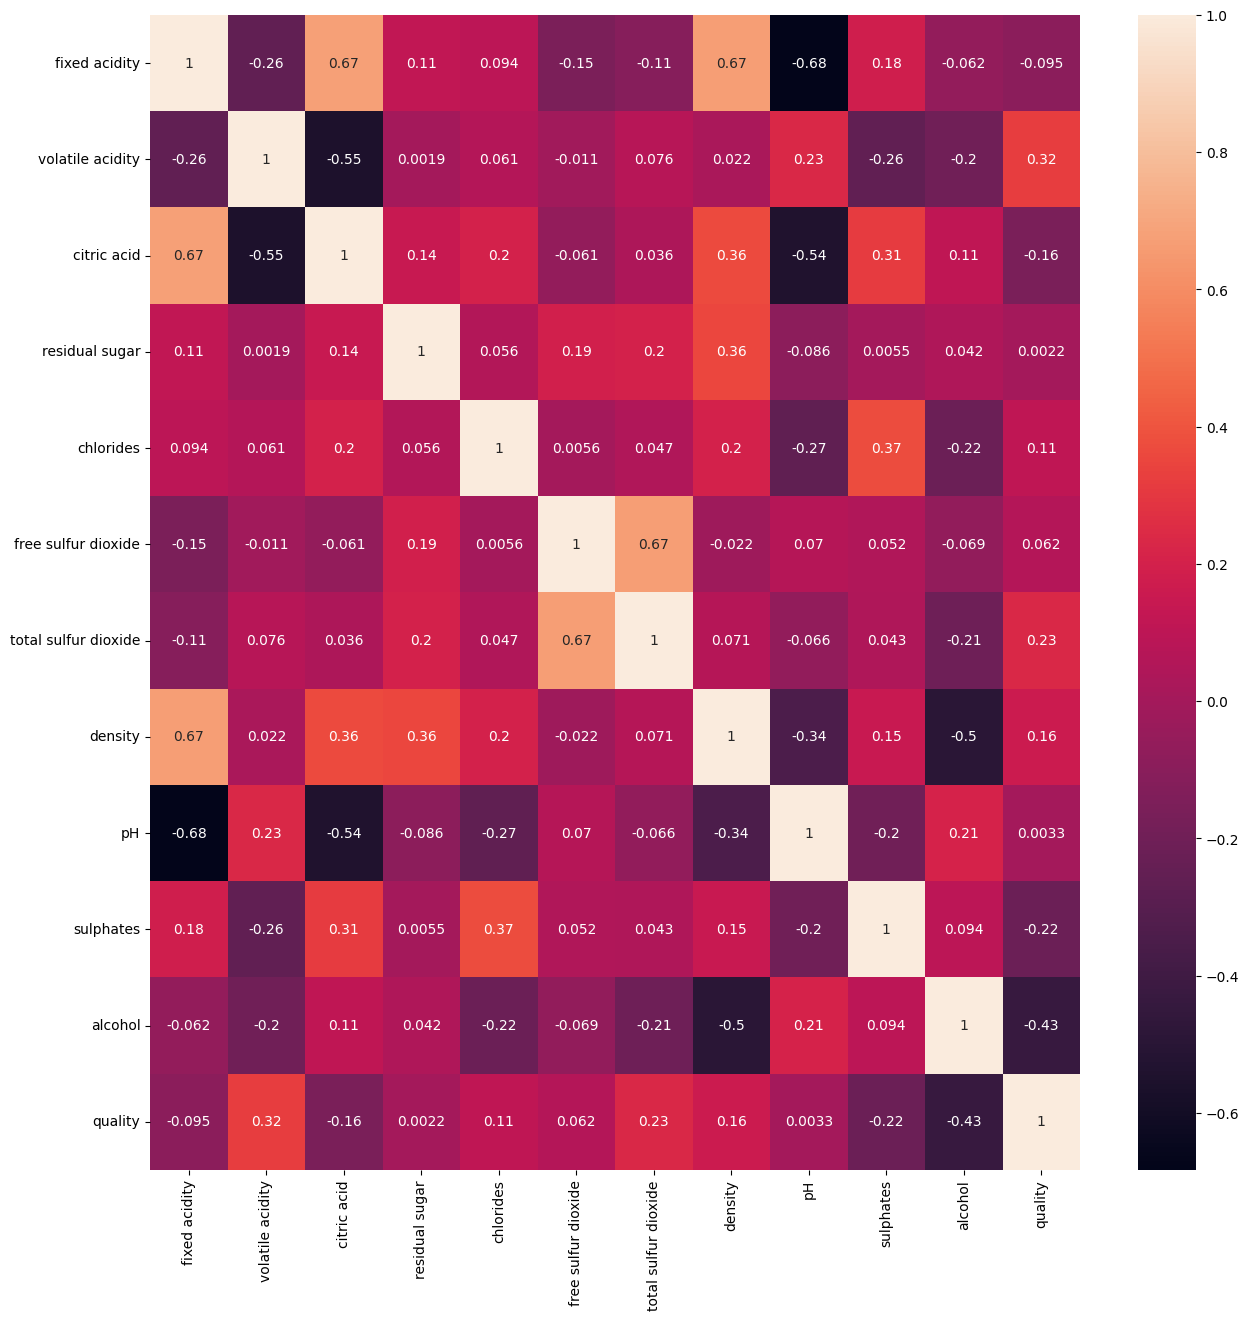

<frozen importlib._bootstrap>:914: ImportWarning: _PyDrive2ImportHook.find_spec() not found; falling back to find_module()
<frozen importlib._bootstrap>:914: ImportWarning: _PyDriveImportHook.find_spec() not found; falling back to find_module()
<frozen importlib._bootstrap>:914: ImportWarning: _GenerativeAIImportHook.find_spec() not found; falling back to find_module()
<frozen importlib._bootstrap>:914: ImportWarning: _OpenCVImportHook.find_spec() not found; falling back to find_module()
<frozen importlib._bootstrap>:914: ImportWarning: APICoreClientInfoImportHook.find_spec() not found; falling back to find_module()
<frozen importlib._bootstrap>:914: ImportWarning: _BokehImportHook.find_spec() not found; falling back to find_module()
<frozen importlib._bootstrap>:914: ImportWarning: _AltairImportHook.find_spec() not found; falling back to find_module()


In [ ]:
matriz_correlacion=dataset.corr()

plt.figure(figsize=(15,15))
sns.heatmap(matriz_correlacion, annot = True)
plt.show()

## Crear Set de Entrenamiento y Set de Test

Vamos a crear un conjunto de entrenamiento con el 80% de los datos y otro conjunto de test con el 20%.

Intentaremos respetar la proporcion de nuestro "target" en ambos conjuntos.

In [ ]:
features=['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
          'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
          'pH', 'sulphates', 'alcohol']

target='quality'

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


In [ ]:
#Verifico balanceo de clases
dataset[target].value_counts(normalize=True)*100

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


,proportion
quality,
0,53.470919
1,46.529081


Los árboles de decisión no suelen estar muy afectados por clases desbalanceadas pero sí es importante tenerlo en cuenta para otros algoritmos de clasificación.

In [ ]:
#Separo un set de Evaluacion
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(dataset[features].values,
                                                    dataset[target].values,
                                                    test_size=0.2,    #20% al conjunto de test
                                                    random_state=13,  #para poder reproducir el experimento
                                                    stratify=dataset[target].values) #estratificado para mantener proporcion

#Verifico Cantidad de Datos en cada set
print('# Datos Entrenamiento: {}'.format(len(x_train)))
print('# Datos Prueba: {}'.format(len(x_test)))

#Verifico como quedaron balanceados
for split_name, split in zip(['% Positivos Entrenamiento','% Positivos Prueba'],[y_train,y_test]):
  print('{}: {:.3f}'.format(split_name,pd.Series(split).value_counts(normalize=True)[1]*100))

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)
<frozen importlib._bootstrap>:914: ImportWarning: _PyDrive2ImportHook.find_spec() not found; falling back to find_module()
<frozen importlib._bootstrap>:914: ImportWarning: _PyDriveImportHook.find_spec() not found; falling back to find_module()
<frozen importlib._bootstrap>:914: ImportWarning: _GenerativeAIImportHook.find_spec() not found; falling back to find_module()
<frozen importlib._bootstrap>:914: ImportWarning: _OpenCVImportHook.find_spec() not found; falling back to find_module()
<frozen importlib._bootstrap>:914: ImportWarning: APICoreClientInfoImportHook.find_spec() not found; falling back to find_module()
<frozen importlib._bo

# Datos Entrenamiento: 1279
# Datos Prueba: 320
% Positivos Entrenamiento: 46.521
% Positivos Prueba: 46.562


<frozen importlib._bootstrap>:914: ImportWarning: _PyDrive2ImportHook.find_spec() not found; falling back to find_module()
<frozen importlib._bootstrap>:914: ImportWarning: _PyDriveImportHook.find_spec() not found; falling back to find_module()
<frozen importlib._bootstrap>:914: ImportWarning: _GenerativeAIImportHook.find_spec() not found; falling back to find_module()
<frozen importlib._bootstrap>:914: ImportWarning: _OpenCVImportHook.find_spec() not found; falling back to find_module()
<frozen importlib._bootstrap>:914: ImportWarning: APICoreClientInfoImportHook.find_spec() not found; falling back to find_module()
<frozen importlib._bootstrap>:914: ImportWarning: _BokehImportHook.find_spec() not found; falling back to find_module()
<frozen importlib._bootstrap>:914: ImportWarning: _AltairImportHook.find_spec() not found; falling back to find_module()
<frozen importlib._bootstrap>:914: ImportWarning: _PyDrive2ImportHook.find_spec() not found; falling back to find_module()
<frozen impo

## Randomized Search Cross Validation

¿Cómo buscar la mejor combinación de hiperparámetros?

Exploramos un espacio de búsqueda, usando k-fold CV para medir el desempeño de cada combinación.
Al terminar, nos quedamos con la combinación con
mejor desempeño y entrenamos un único modelo usando todos los datos de train.

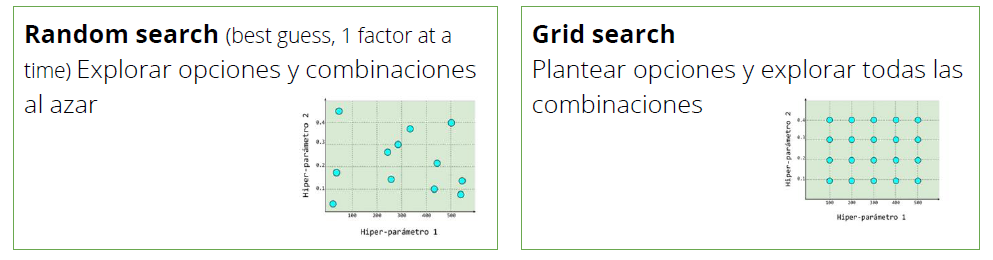

Algunos hiperparámetros de los árboles de decisión
* Criterio de elección de atributos en cada nodo (Information Gain, Gini Gain)
* Criterio de parada (ej: máxima profundidad)
* Estrategia de poda

In [ ]:
##KFOLD CV Random Search para buscar el mejor arbol (los mejores atributos, hiperparametros,etc)
from sklearn.model_selection import StratifiedKFold, KFold,RandomizedSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import make_scorer, f1_score

#Cantidad de combinaciones que quiero porbar
n=10

#Conjunto de parámetros que quiero usar
params_grid = {'criterion':['gini','entropy'],
               #'min_samples_leaf':list(range(1,10)),
               #'min_samples_split': list(range(2,20)),
               'ccp_alpha':np.linspace(0,0.05,n),
               'max_depth': list(range(1,6))}

#Cantidad de splits para el Cross Validation
folds=5

#Kfold estratificado
kfoldcv = StratifiedKFold(n_splits=folds)

#Clasificador
base_tree = DecisionTreeClassifier()

#Metrica que quiero optimizar F1 Score
scorer_fn = make_scorer(f1_score)

#Random Search Cross Validation
randomcv = RandomizedSearchCV(estimator=base_tree,
                              param_distributions = params_grid,
                              scoring=scorer_fn,
                              cv=kfoldcv,
                              n_iter=n)

#Busco los hiperparamtros que optimizan F1 Score
randomcv.fit(x_train,y_train);

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)
<frozen importlib._bootstrap>:914: ImportWarning: _PyDrive2ImportHook.find_spec() not found; falling back to find_module()
<frozen importlib._bootstrap>:914: ImportWarning: _PyDriveImportHook.find_spec() not found; falling back to find_module()
<frozen importlib._bootstrap>:914: ImportWarning: _GenerativeAIImportHook.find_spec() not found; falling back to find_module()
<frozen importlib._bootstrap>:914: ImportWarning: _OpenCVImportHook.find_spec() not found; falling back to find_module()
<frozen importlib._bootstrap>:914: ImportWarning: APICoreClientInfoImportHook.find_spec() not found; falling back to find_module()
<frozen importlib._bo

In [ ]:
randomcv

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)
<frozen importlib._bootstrap>:914: ImportWarning: _PyDrive2ImportHook.find_spec() not found; falling back to find_module()
<frozen importlib._bootstrap>:914: ImportWarning: _PyDriveImportHook.find_spec() not found; falling back to find_module()
<frozen importlib._bootstrap>:914: ImportWarning: _GenerativeAIImportHook.find_spec() not found; falling back to find_module()
<frozen importlib._bootstrap>:914: ImportWarning: _OpenCVImportHook.find_spec() not found; falling back to find_module()
<frozen importlib._bootstrap>:914: ImportWarning: APICoreClientInfoImportHook.find_spec() not found; falling back to find_module()
<frozen importlib._bo

RandomizedSearchCV(cv=StratifiedKFold(n_splits=5, random_state=None, shuffle=False),
                   estimator=DecisionTreeClassifier(),
                   param_distributions={'ccp_alpha': array([0.        , 0.00555556, 0.01111111, 0.01666667, 0.02222222,
       0.02777778, 0.03333333, 0.03888889, 0.04444444, 0.05      ]),
                                        'criterion': ['gini', 'entropy'],
                                        'max_depth': [1, 2, 3, 4, 5]},
                   scoring=make_scorer(f1_score))

In [ ]:
#Mejores hiperparametros del arbol
print(randomcv.best_params_)
#Mejor métrica
print(randomcv.best_score_)

{'max_depth': 5, 'criterion': 'entropy', 'ccp_alpha': 0.016666666666666666}
0.7053653839994465


/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


In [ ]:
pd.DataFrame(randomcv.cv_results_)

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_max_depth,param_criterion,param_ccp_alpha,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,0.009179,0.003326,0.008407,0.002161,2,entropy,0.033333,"{'max_depth': 2, 'criterion': 'entropy', 'ccp_...",0.651163,0.718519,0.609442,0.716049,0.718519,0.682738,0.044809,3
1,0.007558,0.000696,0.011990,0.005008,2,gini,0.044444,"{'max_depth': 2, 'criterion': 'gini', 'ccp_alp...",0.651163,0.718519,0.609442,0.716049,0.718519,0.682738,0.044809,3
2,0.005660,0.002414,0.018471,0.014545,1,entropy,0.044444,"{'max_depth': 1, 'criterion': 'entropy', 'ccp_...",0.651163,0.718519,0.609442,0.716049,0.718519,0.682738,0.044809,3
3,0.032113,0.015985,0.016669,0.007215,5,gini,0.016667,"{'max_depth': 5, 'criterion': 'gini', 'ccp_alp...",0.651163,0.718519,0.609442,0.716049,0.718519,0.682738,0.044809,3
4,0.020557,0.005222,0.010482,0.001601,5,entropy,0.016667,"{'max_depth': 5, 'criterion': 'entropy', 'ccp_...",0.699647,0.718519,0.609442,0.739726,0.759494,0.705365,0.051995,1
5,0.017026,0.002687,0.013990,0.003786,4,gini,0.005556,"{'max_depth': 4, 'criterion': 'gini', 'ccp_alp...",0.647303,0.750000,0.633929,0.713115,0.701613,0.689192,0.042972,2
6,0.017468,0.004452,0.008507,0.001522,5,gini,0.022222,"{'max_depth': 5, 'criterion': 'gini', 'ccp_alp...",0.651163,0.718519,0.609442,0.716049,0.718519,0.682738,0.044809,3
7,0.021599,0.003100,0.015308,0.003184,5,gini,0.05,"{'max_depth': 5, 'criterion': 'gini', 'ccp_alp...",0.651163,0.718519,0.609442,0.716049,0.718519,0.682738,0.044809,3
8,0.016586,0.002763,0.014574,0.001310,4,gini,0.016667,"{'max_depth': 4, 'criterion': 'gini', 'ccp_alp...",0.651163,0.718519,0.609442,0.716049,0.718519,0.682738,0.044809,3
9,0.004486,0.000956,0.008395,0.002671,1,entropy,0.0,"{'max_depth': 1, 'criterion': 'entropy', 'ccp_...",0.651163,0.718519,0.609442,0.716049,0.718519,0.682738,0.044809,3


In [ ]:
randomcv.cv_results_['mean_test_score']

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


array([0.68273825, 0.68273825, 0.68273825, 0.68273825, 0.70536538,
       0.68919183, 0.68273825, 0.68273825, 0.68273825, 0.68273825])

In [ ]:
#Atributos considerados y su importancia
best_tree = randomcv.best_estimator_
feat_imps = best_tree.feature_importances_

for feat_imp,feat in sorted(zip(feat_imps,features)):
  if feat_imp>0:
    print('{}: {}'.format(feat,feat_imp))


sulphates: 0.2631646151150383
alcohol: 0.7368353848849617


/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


TODO: Graficar el mejor árbol obtenido

TODO: Probar GridSearch Cross Validation

In [ ]:
from sklearn.model_selection import GridSearchCV

#Cantidad de combinaciones que quiero porbar
#n=

#Conjunto de parámetros que quiero usar
#params_grid = {}

#Cantidad de splits para el Cross Validation
#folds=

#Kfold estratificado
#kfoldcv = StratifiedKFold(n_splits=folds)

#Clasificador
#base_tree = DecisionTreeClassifier()

#Metrica que quiero optimizar F1 Score
#scorer_fn = make_scorer(f1_score)

#GridSearch CV
gridcv = GridSearchCV(estimator=base_tree ,
                      param_grid=params_grid,
                      scoring=scorer_fn,
                      cv=kfoldcv,
                      return_train_score='True')

#gridcv.fit(x_train,y_train)

#gridcv.cv_results_
#etc....

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


## Predicción y Evaluación del Modelo con mejores hiperparámetros

In [ ]:
#Creo el árbol con los mejores hiperparámetros
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import export_text

arbol=DecisionTreeClassifier().set_params(**randomcv.best_params_)

#Entreno el arbol en todo el set
arbol.fit(x_train,y_train)

reglas = export_text(arbol, feature_names=list(features))
print(reglas)

|--- alcohol <= 10.55
|   |--- sulphates <= 0.53
|   |   |--- class: 1
|   |--- sulphates >  0.53
|   |   |--- alcohol <= 9.85
|   |   |   |--- class: 1
|   |   |--- alcohol >  9.85
|   |   |   |--- class: 0
|--- alcohol >  10.55
|   |--- sulphates <= 0.58
|   |   |--- alcohol <= 11.45
|   |   |   |--- class: 1
|   |   |--- alcohol >  11.45
|   |   |   |--- class: 0
|   |--- sulphates >  0.58
|   |   |--- class: 0



/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)
<frozen importlib._bootstrap>:914: ImportWarning: _PyDrive2ImportHook.find_spec() not found; falling back to find_module()
<frozen importlib._bootstrap>:914: ImportWarning: _PyDriveImportHook.find_spec() not found; falling back to find_module()
<frozen importlib._bootstrap>:914: ImportWarning: _GenerativeAIImportHook.find_spec() not found; falling back to find_module()
<frozen importlib._bootstrap>:914: ImportWarning: _OpenCVImportHook.find_spec() not found; falling back to find_module()
<frozen importlib._bootstrap>:914: ImportWarning: APICoreClientInfoImportHook.find_spec() not found; falling back to find_module()
<frozen importlib._bo

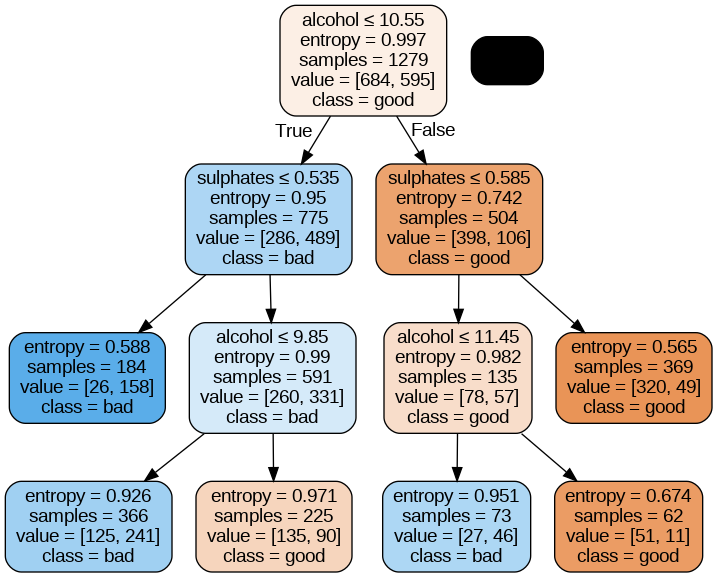

In [ ]:
from six import StringIO
from IPython.display import Image
from sklearn.tree import export_graphviz
import pydotplus
import matplotlib.pyplot as plt

dot_data = StringIO()
export_graphviz(arbol, out_file=dot_data,
                filled=True, rounded=True,
                special_characters=True,
                feature_names=features,
                class_names=['good','bad'])

graph = pydotplus.graph_from_dot_data(dot_data.getvalue())
Image(graph.create_png())

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


F1-Score: 0.7070063694267515


Text(50.722222222222214, 0.5, 'True')

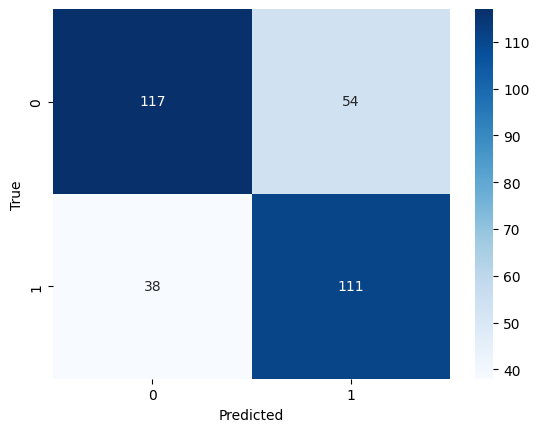

In [ ]:
#Evalúo el Arbol con los mejores hiperparámetros
from sklearn.metrics import confusion_matrix, classification_report , f1_score

#Hago predicción sobre el set de evaluacion
y_pred= arbol.predict(x_test)

#Arbol Reporte y Matriz de Confusion
#print(classification_report(y_test,y_pred))
print('F1-Score: {}'.format(f1_score(y_test, y_pred, average='binary'))) #binary considera la clase positiva por defecto 1

cm = confusion_matrix(y_test,y_pred)
sns.heatmap(cm, cmap='Blues',annot=True,fmt='g')
plt.xlabel('Predicted')
plt.ylabel('True')

In [ ]:
arbol.predict_proba(x_test)

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


array([[0.34153005, 0.65846995],
       [0.86720867, 0.13279133],
       [0.34153005, 0.65846995],
       [0.6       , 0.4       ],
       [0.34153005, 0.65846995],
       [0.34153005, 0.65846995],
       [0.86720867, 0.13279133],
       [0.34153005, 0.65846995],
       [0.14130435, 0.85869565],
       [0.86720867, 0.13279133],
       [0.34153005, 0.65846995],
       [0.34153005, 0.65846995],
       [0.82258065, 0.17741935],
       [0.6       , 0.4       ],
       [0.36986301, 0.63013699],
       [0.34153005, 0.65846995],
       [0.6       , 0.4       ],
       [0.86720867, 0.13279133],
       [0.34153005, 0.65846995],
       [0.86720867, 0.13279133],
       [0.36986301, 0.63013699],
       [0.86720867, 0.13279133],
       [0.86720867, 0.13279133],
       [0.14130435, 0.85869565],
       [0.82258065, 0.17741935],
       [0.14130435, 0.85869565],
       [0.34153005, 0.65846995],
       [0.14130435, 0.85869565],
       [0.6       , 0.4       ],
       [0.86720867, 0.13279133],
       [0.

## Entrenamiento Cross Validation

Veamos qué pasa con las métricas si entrenamos el mismo árbol con diferentes conjuntos de datos (en este caso con cada split de un CV)

In [ ]:
#Entrenamiento con 10 Fold Cross Validation
from sklearn.model_selection import cross_validate, StratifiedKFold

# Spits que respeten la proporción delas clases
kfoldcv =StratifiedKFold(n_splits=10)

#Creo árbol con los mejores hiperparámetros
arbolcv=DecisionTreeClassifier()#.set_params(**randomcv.best_params_)

#Selecciono métrica F1-Score
scorer_fn = make_scorer(f1_score)

#Hago CV
resultados = cross_validate(arbolcv,
                            x_train, y_train,
                            cv=kfoldcv,
                            scoring=scorer_fn,
                            return_estimator=True)

metricsCV=resultados['test_score']
mejor_performance=resultados['estimator'][np.where(metricsCV==max(metricsCV))[0][0]]


/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


In [ ]:
resultados

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


{'fit_time': array([0.02692413, 0.03981781, 0.04696345, 0.02327323, 0.02276063,
        0.01576686, 0.01610065, 0.01672125, 0.06490088, 0.03381181]),
 'score_time': array([0.01147795, 0.01330781, 0.01279855, 0.00672412, 0.0153079 ,
        0.0055213 , 0.00605631, 0.00690031, 0.01144552, 0.00530076]),
 'estimator': [DecisionTreeClassifier(),
  DecisionTreeClassifier(),
  DecisionTreeClassifier(),
  DecisionTreeClassifier(),
  DecisionTreeClassifier(),
  DecisionTreeClassifier(),
  DecisionTreeClassifier(),
  DecisionTreeClassifier(),
  DecisionTreeClassifier(),
  DecisionTreeClassifier()],
 'test_score': array([0.69421488, 0.71186441, 0.73504274, 0.71929825, 0.64347826,
        0.70689655, 0.72580645, 0.77966102, 0.73043478, 0.8173913 ])}

In [ ]:
metricsCV

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


array([0.69421488, 0.71186441, 0.73504274, 0.71929825, 0.64347826,
       0.70689655, 0.72580645, 0.77966102, 0.73043478, 0.8173913 ])

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)
<frozen importlib._bootstrap>:914: ImportWarning: _PyDrive2ImportHook.find_spec() not found; falling back to find_module()
<frozen importlib._bootstrap>:914: ImportWarning: _PyDriveImportHook.find_spec() not found; falling back to find_module()
<frozen importlib._bootstrap>:914: ImportWarning: _GenerativeAIImportHook.find_spec() not found; falling back to find_module()
<frozen importlib._bootstrap>:914: ImportWarning: _OpenCVImportHook.find_spec() not found; falling back to find_module()
<frozen importlib._bootstrap>:914: ImportWarning: APICoreClientInfoImportHook.find_spec() not found; falling back to find_module()
<frozen importlib._bo

<Axes: >

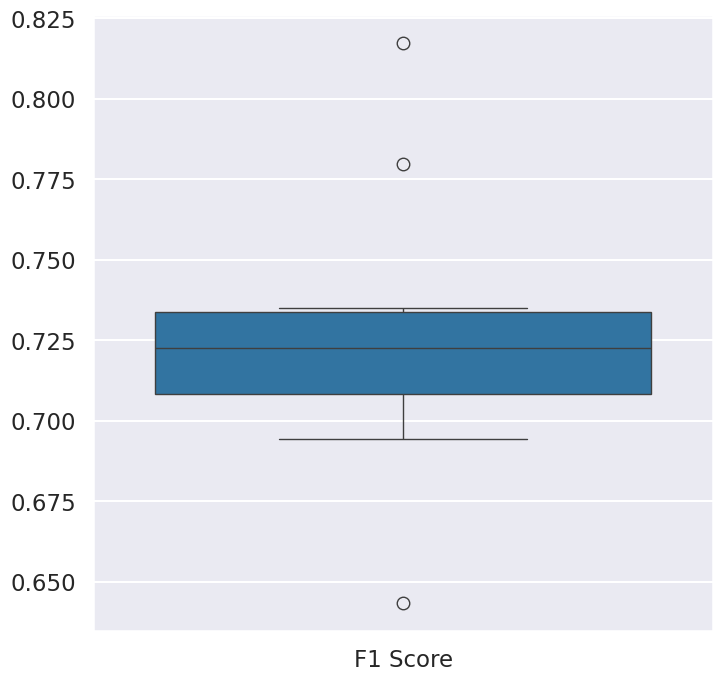

In [ ]:
#Grafico Boxplot -Entrenado con 10 Fold Cross Validation

metric_labelsCV = ['F1 Score']*len(metricsCV)
sns.set_context('talk')
sns.set_style("darkgrid")
plt.figure(figsize=(8,8))
sns.boxplot(x = metric_labelsCV,y=metricsCV)

In [ ]:
#Importancia y reglas del Árbol con mejor Performance
from sklearn.tree import export_text

feat_imps = mejor_performance.feature_importances_

for feat_imp,feat in sorted(zip(feat_imps,features)):
  if feat_imp>0:
    print('{}: {}'.format(feat,feat_imp))
print()

reglas = export_text(mejor_performance, feature_names=list(features))
print(reglas)

residual sugar: 0.037096307344011155
free sulfur dioxide: 0.04617842366917123
pH: 0.04729586905251229
citric acid: 0.0493917566694931
density: 0.05587210019591385
chlorides: 0.06767556936055859
sulphates: 0.0994033499411214
total sulfur dioxide: 0.10300183102788386
fixed acidity: 0.10532587337622547
volatile acidity: 0.12653985821842617
alcohol: 0.2622190611446828

|--- alcohol <= 10.55
|   |--- sulphates <= 0.53
|   |   |--- volatile acidity <= 0.34
|   |   |   |--- density <= 1.00
|   |   |   |   |--- class: 1
|   |   |   |--- density >  1.00
|   |   |   |   |--- class: 0
|   |   |--- volatile acidity >  0.34
|   |   |   |--- alcohol <= 9.65
|   |   |   |   |--- residual sugar <= 9.00
|   |   |   |   |   |--- volatile acidity <= 0.56
|   |   |   |   |   |   |--- pH <= 3.24
|   |   |   |   |   |   |   |--- class: 1
|   |   |   |   |   |   |--- pH >  3.24
|   |   |   |   |   |   |   |--- pH <= 3.31
|   |   |   |   |   |   |   |   |--- total sulfur dioxide <= 112.00
|   |   |   |   |   

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


In [ ]:
#Grafico
dot_data = StringIO()
export_graphviz(mejor_performance, out_file=dot_data,
                filled=True, rounded=True,
                special_characters=True,
                feature_names=features,
                class_names=['good','bad'])

graph = pydotplus.graph_from_dot_data(dot_data.getvalue())
Image(graph.create_png())

Output hidden; open in https://colab.research.google.com to view.

## Predicción y Evaluación del Modelo

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


              precision    recall  f1-score   support

           0       0.75      0.77      0.76       171
           1       0.73      0.70      0.72       149

    accuracy                           0.74       320
   macro avg       0.74      0.74      0.74       320
weighted avg       0.74      0.74      0.74       320



Text(34.08333333333333, 0.5, 'True')

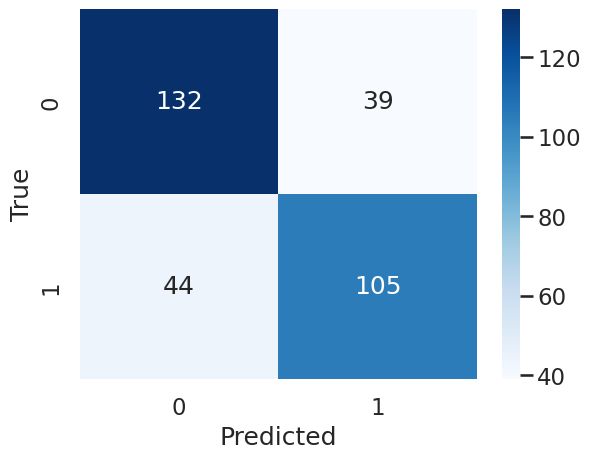

In [ ]:
#Arbol CV set de evaluación

from sklearn.metrics import confusion_matrix, classification_report
from sklearn.tree import DecisionTreeClassifier

#Predicción sobre el set de evaluacion
y_pred= mejor_performance.predict(x_test)

#Arbol Reporte y Matriz de Confusion
print(classification_report(y_test,y_pred))

cm = confusion_matrix(y_test,y_pred)
sns.heatmap(cm, cmap='Blues',annot=True,fmt='g')
plt.xlabel('Predicted')
plt.ylabel('True')